In [ ]:
!pip install transformers datasets scikit-learn torch

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from datasets import Dataset
import torch
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [2]:
df = pd.read_csv('data_for_embedding.csv', sep=';')

In [3]:
df['label'].value_counts()

label
No Online Gambling Promotion    7821
Online Gambling Promotion       4179
Name: count, dtype: int64

In [4]:
df = df.drop(['video_id', 'video_title'], axis=1)

In [5]:

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  12000 non-null  object
 1   label    12000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 187.6+ KB


In [7]:
xtemp, xtest, ytemp, ytest = train_test_split(df['comment'], df['label'], test_size=0.2, stratify=df['label'], random_state=42)

xtemp = np.array(xtemp)
ytemp = np.array(ytemp)

In [8]:
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize(t):
  return tokenizer(t.tolist(), padding=True, truncation=True, return_tensors=None)

In [9]:
class CommentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [10]:
def model_initialize():
    return BertForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=2)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    }

In [14]:
learning_rates = [2e-5, 3e-5]
epochs = [2]

best_metric = -999
best_model_state = None
best_hp = None
fold_scores = []

In [13]:
from transformers import EarlyStoppingCallback
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_metric = -999
best_hp = None
best_model_state = None
fold_scores = []

for lr in learning_rates:
    for ep in epochs:

        print(f"\n### Trying HP: LR={lr}, epochs={ep} ###")

        fold_metrics = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(xtemp, ytemp)):
            print(f"\n===== Fold {fold+1} =====")

            xtr, xval = xtemp[train_idx], xtemp[val_idx]
            ytr, yval = ytemp[train_idx], ytemp[val_idx]

            # Tokenize
            xtr_t = tokenize(xtr)
            xval_t = tokenize(xval)

            train_d = CommentDataset(xtr_t, ytr.tolist())
            val_d = CommentDataset(xval_t, yval.tolist())

            # Model
            model = BertForSequenceClassification.from_pretrained(
                "indobenchmark/indobert-base-p1",
                num_labels=2
            )

            training_args = TrainingArguments(
                output_dir=f'./result_hp_{lr}_{ep}',
                num_train_epochs=ep,
                per_device_train_batch_size=16,
                per_device_eval_batch_size=64,
                learning_rate=lr,
                warmup_steps=200,
                weight_decay=0.01,
                logging_steps=20,
                eval_strategy="epoch",

                # ---- FIXED ----
                metric_for_best_model="eval_f1_weighted",
                greater_is_better=True,
                save_strategy="epoch",

                load_best_model_at_end=True
            )

            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=train_d,
                eval_dataset=val_d,

                # ---- FIXED ----
                compute_metrics=lambda pred: {
                    "accuracy": accuracy_score(pred.label_ids, pred.predictions.argmax(-1)),
                    "f1_weighted": f1_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted"),
                    "precision_weighted": precision_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted"),
                    "recall_weighted": recall_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted")
                },

                tokenizer=tokenizer,
                callbacks=[EarlyStoppingCallback(1)]
            )

            trainer.train()
            eval_result = trainer.evaluate()

            # ---- FIXED ----
            fold_metrics.append(eval_result["eval_f1_weighted"])

        # CV Mean weighted F1 for this hyperparameter
        avg_f1 = np.mean(fold_metrics)
        fold_scores.append(avg_f1)

        print(f"Average weighted F1 for LR={lr}, EP={ep}: {avg_f1:.4f}")

        # ---- FIXED ----
        if avg_f1 > best_metric:
            best_metric = avg_f1
            best_hp = (lr, ep)
            best_model_state = trainer.model.state_dict().copy()



### Trying HP: LR=2e-05, epochs=2 ###

===== Fold 1 =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1368/3157824836.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.134800,0.147207,0.954688,0.954445,0.954688,0.954688
2,0.077700,0.141947,0.957812,0.957820,0.957828,0.957812



===== Fold 2 =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1368/3157824836.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.158800,0.147499,0.952083,0.951981,0.951960,0.952083
2,0.102200,0.146075,0.954167,0.954229,0.954328,0.954167
3,0.034200,0.149116,0.958854,0.958847,0.958840,0.958854



===== Fold 2 =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1368/3157824836.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.162700,0.143969,0.950000,0.949819,0.949865,0.950000


KeyboardInterrupt: 

In [15]:
from transformers import EarlyStoppingCallback
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

best_metric = -999
best_hp = None
best_model_state = None
fold_scores = []

for lr in learning_rates:
    for ep in epochs:

        print(f"\n### Trying HP: LR={lr}, epochs={ep} ###")

        fold_metrics = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(xtemp, ytemp)):
            print(f"\n===== Fold {fold+1} =====")

            xtr, xval = xtemp[train_idx], xtemp[val_idx]
            ytr, yval = ytemp[train_idx], ytemp[val_idx]

            # Tokenize
            xtr_t = tokenize(xtr)
            xval_t = tokenize(xval)

            train_d = CommentDataset(xtr_t, ytr.tolist())
            val_d = CommentDataset(xval_t, yval.tolist())

            # Model
            model = BertForSequenceClassification.from_pretrained(
                "indobenchmark/indobert-base-p1",
                num_labels=2
            )

            training_args = TrainingArguments(
                output_dir=f'./result_hp_{lr}_{ep}',
                num_train_epochs=ep,
                per_device_train_batch_size=16,
                per_device_eval_batch_size=64,
                learning_rate=lr,
                warmup_steps=200,
                weight_decay=0.01,
                logging_steps=20,
                eval_strategy="epoch",

                # ---- FIXED ----
                metric_for_best_model="eval_f1_weighted",
                greater_is_better=True,
                save_strategy="epoch",

                load_best_model_at_end=True
            )

            trainer = Trainer(
                model=model,
                args=training_args,
                train_dataset=train_d,
                eval_dataset=val_d,

                # ---- FIXED ----
                compute_metrics=lambda pred: {
                    "accuracy": accuracy_score(pred.label_ids, pred.predictions.argmax(-1)),
                    "f1_weighted": f1_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted"),
                    "precision_weighted": precision_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted"),
                    "recall_weighted": recall_score(pred.label_ids, pred.predictions.argmax(-1), average="weighted")
                },

                tokenizer=tokenizer,
                callbacks=[EarlyStoppingCallback(1)]
            )

            trainer.train()
            eval_result = trainer.evaluate()

            # ---- FIXED ----
            fold_metrics.append(eval_result["eval_f1_weighted"])

        # CV Mean weighted F1 for this hyperparameter
        avg_f1 = np.mean(fold_metrics)
        fold_scores.append(avg_f1)

        print(f"Average weighted F1 for LR={lr}, EP={ep}: {avg_f1:.4f}")

        # ---- FIXED ----
        if avg_f1 > best_metric:
            best_metric = avg_f1
            best_hp = (lr, ep)
            best_model_state = trainer.model.state_dict().copy()



### Trying HP: LR=2e-05, epochs=2 ###

===== Fold 1 =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1368/1851655709.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.162500,0.157544,0.943958,0.944054,0.944205,0.943958
2,0.103200,0.166160,0.951667,0.951803,0.952097,0.951667



===== Fold 2 =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1368/1851655709.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.154000,0.172267,0.942708,0.942859,0.943144,0.942708
2,0.100200,0.173529,0.949583,0.949686,0.949869,0.949583



===== Fold 2 =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1368/1851655709.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.204300,0.157233,0.946250,0.946594,0.947812,0.946250
2,0.097900,0.145349,0.955000,0.955031,0.955071,0.955000


Average weighted F1 for LR=3e-05, EP=2: 0.9524


In [ ]:
torch.save(best_model_state, "best_model.bin")
print("Saved best model to best_model.bin")


Saved best model to best_model.bin


In [ ]:
xtest_t = tokenizer(xtest.tolist(), padding=True, truncation=True)
test_d = CommentDataset(xtest_t, ytest.tolist())

final_model = BertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=2
)
final_model.load_state_dict(torch.load("best_model.bin", map_location="cpu"))
final_model.eval()

test_args = TrainingArguments(
    output_dir="./final_eval",
    per_device_eval_batch_size=64,
    do_train=False,
    do_eval=True,
    logging_steps=20
)
final_trainer = Trainer(
    model=final_model,
    args=test_args,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    eval_dataset=test_d
)
test_metrics = final_trainer.evaluate(test_d)
print("\n==== Test Set Metrics ====")
print(test_metrics)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1368/2751340486.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_g


==== Test Set Metrics ====
{'eval_loss': 0.14143532514572144, 'eval_model_preparation_time': 0.0021, 'eval_accuracy': 0.95625, 'eval_f1': 0.9375371802498513, 'eval_precision': 0.9325443786982248, 'eval_recall': 0.9425837320574163, 'eval_runtime': 393.539, 'eval_samples_per_second': 6.099, 'eval_steps_per_second': 0.097}


In [22]:
def bootstrap_ci(labels, preds, metric_fn, n=1000):
    stats = []
    labels, preds = np.array(labels), np.array(preds)
    for _ in range(n):
        idx = np.random.choice(len(labels), len(labels), replace=True)
        stats.append(metric_fn(labels[idx], preds[idx]))
    return np.mean(stats), 1.96*np.std(stats)

pred_output = final_trainer.predict(test_d)
preds = np.argmax(pred_output.predictions, axis=1)
probs = pred_output.predictions
labels = pred_output.label_ids

test_mean, test_ci = bootstrap_ci(labels, preds,
    lambda a,b: f1_score(a,b,average='weighted')
)

print(f"\nTest Weighted F1 (bootstrap): {test_mean:.4f} ± {test_ci:.4f}\n")



Test Weighted F1 (bootstrap): 0.9562 ± 0.0084



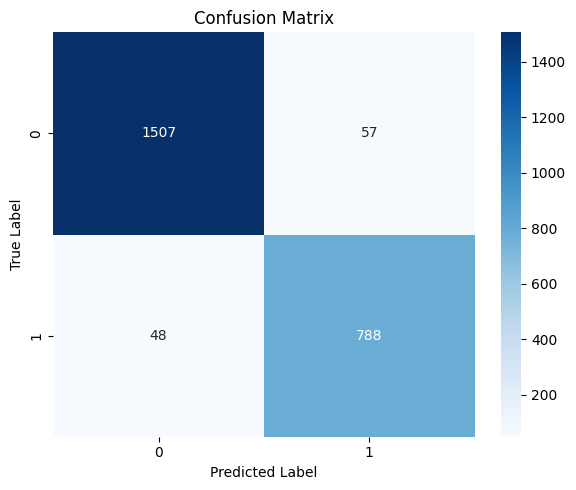

In [23]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


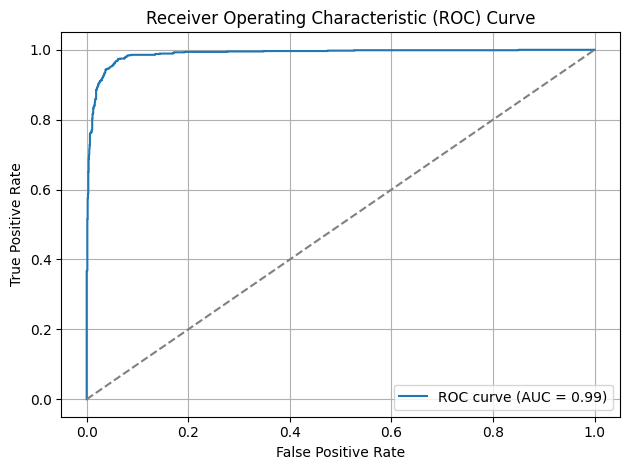

ROC AUC Score: 0.988724


In [32]:
from sklearn.preprocessing import label_binarize

# Binary classification assumed (labels: 0, 1)
fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"ROC AUC Score: {roc_auc:.6f}")


In [26]:
print("Classification Report:")
print(classification_report(labels, preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1564
           1       0.93      0.94      0.94       836

    accuracy                           0.96      2400
   macro avg       0.95      0.95      0.95      2400
weighted avg       0.96      0.96      0.96      2400



In [31]:
acc  = accuracy_score(labels, preds)
f1_w = f1_score(labels, preds, average='weighted')
prec_w = precision_score(labels, preds, average='weighted')
rec_w = recall_score(labels, preds, average='weighted')
print(f"Accuracy (weighted):       {acc:.6f}")
print(f"Precision (weighted):      {prec_w:.6f}")
print(f"Recall (weighted):         {rec_w:.6f}")
print(f"F1-Score (weighted):       {f1_w:.6f}")

Accuracy (weighted):       0.956250
Precision (weighted):      0.956387
Recall (weighted):         0.956250
F1-Score (weighted):       0.956304


In [27]:
model.save_pretrained('hp_saved_model/INDOBERTbase')
tokenizer.save_pretrained('hp_saved_model/INDOBERTbase')

('hp_saved_model/INDOBERTbase/tokenizer_config.json',
 'hp_saved_model/INDOBERTbase/special_tokens_map.json',
 'hp_saved_model/INDOBERTbase/vocab.txt',
 'hp_saved_model/INDOBERTbase/added_tokens.json')